# Monte Carlo


gera numeros aleatórios, ve se ta dentro ou fora da condição do exercicio

## Radioactive decay chain


${\rm Tl}^{208}$ decays to ${\rm Pb}^{208}$ with a half-lieve of 3.052 minutes. Suppose to start with a sample of 1000 Thallium atoms and 0 of Lead atoms.

* Take steps in time of 1 second and at each time-step decide whether each Tl atom has decayed or not, accordingly to the probability $p(t)=1-2^{-t/\tau}$. Subtract the total number of Tl atoms that decayed at each step from the Tl sample and add them to the Lead one. Plot the evolution of the two sets as a function of time  
* Repeat the exercise by means of the inverse transform method: draw 1000 random numbers from the non-uniform probability distribution $p(t)=2^{-t/\tau}\frac{\ln 2}{\tau}$ to represent the times of decay of the 1000 Tl atoms. Make a plot showing the number of atoms that have not decayed as a function of time

In [23]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
tau = 3.052 * 60 #minutes to seconds
Tl_i = 1000 # atoms
Pb_i = 0 # atoms - initial sample
dt = 1 #1 second step
p_decay = 1 - 2**(-dt/tau)
T_max = 1500        # total time (seconds)

Tl_hist = [] #final tl: tl - decayed
Pb_hist = [] #final pb: pb + decayed


#como eu tenho q calcular a probabilidade em cada step, um arrange de cada tempo a ser calculado
times = np.arange(0, T_max, dt)

In [ ]:
#Monte carlo: draw a random number between 0 and 1, if it is smaller than p_decay, then the atom decays
np.random.seed(42) #seed for reproducibility
for i in range(len(times)):
    
    num_dec = np.sum(np.random.random(Tl_i) < p_decay) #since we're deciding over the number of atoms the prob

    Tl_i -= num_dec #Altera o numero de Tl_i, diminuindo o numero de decaidos
    Pb_i += num_dec

    Tl_hist.append(Tl_i)
    Pb_hist.append(Pb_i) #salva o historico

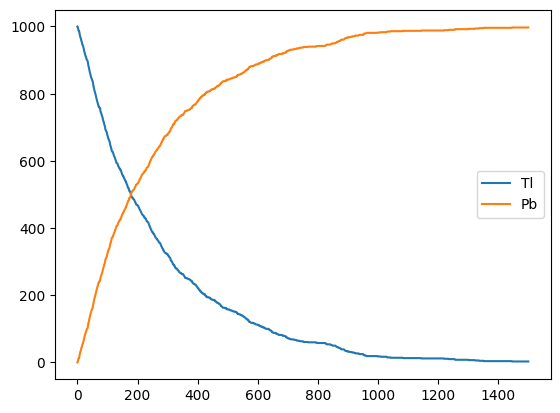

In [8]:
plt.plot(np.linspace(0,T_max,1500),Tl_hist, label = 'Tl')
plt.plot(np.linspace(0,T_max,1500),Pb_hist, label = 'Pb')
plt.legend()

In [17]:
# Inverse transform method:
N = 1000 #number of random draws

#pdf: 
#pdf_t = np.log(2)/tau * 2**(-t/tau)
#cdf: integral de pdf de 0 a t
#cdf_t = 1 - 2**(-t/tau)
#inverse cdf -> U = F(t) e depois isola t
T_inverse_cdf = (-tau/np.log(2))*(np.log(1 - np.random.random(N))) #draws from uniform distribution

Tl_alive = []

for t in times:
    alive = np.sum(T_inverse_cdf > t) #mostra quantos ainda estao vivos em cada segundo do tempo
    Tl_alive.append(alive)

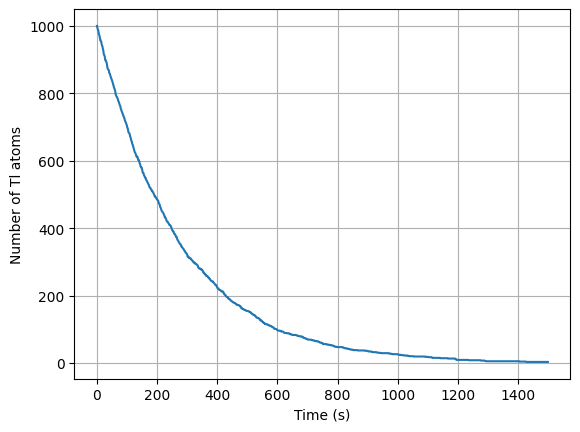

In [18]:
plt.plot(times, Tl_alive)
plt.xlabel("Time (s)")
plt.ylabel("Number of Tl atoms")
plt.grid()

### Summarize:

**primeira parte:** 
* cria as variaveis
* cria as listas de tl e pb
* cria a 'linha de tempo - arange'
* for i in times:
* soma de np.random.random(atomos de tl) < prob
* sub em tl; add em pb
* plota

**segunda parte:**
* tem a pdf: integra pra cdf
* u = F(T) -> isola T
* obtem a funcao q transforma a uniforme em tempo
* lista de t historico alive
* for t in times:
* se o tempo_morreu(inverse cdf) > t -> vivo
* append of ta vivo
* plota ao longo do tempo

## Rutherford Scattering

The scattering angle $\theta$ of $\alpha$ particles hitting a positively charged nucleus of a Gold atom ($Z=79$) follows the rule:

$$
\tan{\frac{1}{2} \theta} = \frac{Z e^2} {2\pi \epsilon_0 E b}
$$

where $E=7.7$ MeV and $b$ beam is the impact parameter. The beam is represented by a 2D gaussian distribution with $\sigma=a_0/100$ for both coordinates ($a_0$ being the Bohr radius). Assume 1 million $\alpha$ particles are shot on the gold atom.

Computing the fraction of particles that "bounce back",i.e. those particle whose scattering angle is greater than $\pi/2$ (which set a condition on the impact parameter $b$)

In [19]:
import scipy.constants as const

In [22]:
print(const.physical_constants["Bohr radius"])
print(const.physical_constants["Bohr radius"][0])

(5.29177210544e-11, 'm', 8.2e-21)
5.29177210544e-11


In [29]:
Z = 79 #nucleus of gold 
E = 7.7e6 * const.eV #Mev to Joules
a0 = const.physical_constants["Bohr radius"][0]
e = const.e
epsilon_0 = const.epsilon_0
sigma = a0/100
N_alpha = 10**6
angle_crit = np.pi/2
b_crit = Z*(e**2)/(2*np.pi*epsilon_0*E)

In [30]:
#Now to generate the 2D Gaussian distribution
np.random.seed(42) #seed for reproducibility
x = np.random.normal(0, sigma, N_alpha) #centro do ouro em (0,0)
y = np.random.normal(0, sigma, N_alpha) 

#given that b is the distance from the center, them:
b = np.sqrt(x**2 + y**2)

#to know what bounced:
n_bounce = np.sum(b < b_crit) #se b for menor que o threshold, entao bounce
fraction_bounce = n_bounce/N_alpha

In [33]:
print(n_bounce,'\n',fraction_bounce*100)

1534 
 0.1534


### Summarize:

* scipy.constants - tem tudo la
* transformar E em Joule: E(joule) = E(mev) * 10**6 * constante.eV
* tan $\pi/4$ = 1
* b pequeno -> $\theta$ grande, então o angulo tem que ser maior que  $\pi/2$
* isola b
* substitui tudo
* gera duas normais para x e y (0,sigma)
* b é a distancia (euclidiana de x e y)
* b < b critico -> então bounce

## Monte Carlo integration: hit/miss vs mean value method


Consider the function 

$$f(x) =\sin^2{\frac{1}{x(2-x)}}$$

* Compute the integral of $f(x)$ between 0 and 2 with the hit/miss method. Evaluate the error of your estimate
* Repeat the integral with the mean value method. Evaluate the error and compare it with the previous one

In [48]:
#Hit and miss method:está no monte carlo notebook
def f(x):
    return np.sin(1/(x*(2-x)))**2

#integration limits:
a,b = 0.0001, 1.9999 #avoid singularities at 0 and 2
N = 1000000 #number of random draws
np.random.seed(42)

In [52]:
x=np.linspace(a,b,1000)
count=0
for i in range(N):
    x=2*np.random.random() #se tor integrando de 0 a 2, np random gera de 0 a 1
    y=np.random.random() #pq a funcão sin vai no maximo a 1
    if y<f(x): count+=1 #se estiver dentro da função é success
I=2*count/N #2 é a area

#para calcular o erro: area * raiz(hits *(n-hits)/N)
error = 2 * np.sqrt((count/N) * (1 - count/N) / N)

print(I, "+-", error)

1.451112 +- 0.0008924673458765872


In [55]:
#Mean Value Method
for i in range(N):
    I = (2 / N) * np.sum(f(x))
errormv = 2 * np.std(f(x)) / np.sqrt(N) #erro do mean value method    
print(I, "+-", errormv)    

1.4565556008016826e-06 +- 0.0


### Summarize:
* def f(x)
* pega do notebook de montecarlo o hit and miss
* nao deixa exatamente 0 e 2, para evitar singularities
* calcula a area do retangulo baseado nos limites da função
* erro hit miss: area * sqrt((count/N) * (1 - count/N) / N)
* para mean value só aplicar a formula do enunciado

## Monte Carlo integration in high dimension

* Start of by computing the area of a circle of unit radius, by integrating the function 

$$
f(x,y)=
\left\{
\begin{array}{ll}
      1 & x^2+y^2\le 1 \\
      0 & {\rm elsewhere}
\end{array} 
\right.
$$

* Generalize the result for a 10D sphere


In [66]:
N = 1000000 #number of random draws
#To compute the area do a circle with radius 1
x = np.random.uniform(-1, 1, N) # podem cair em qualquer ponto do quadrado de area 2x2
y = np.random.uniform(-1, 1, N)

rinside2 = x**2 + y**2 <= 1 #aqui aplico minha condição

hits = np.sum(rinside2)

areacirculo = (4/N)*hits #area quadrado * hits / N

erro = 2**2 * np.sqrt(np.var(rinside2)/N) #area do quadrado * raiz(variancia/N)
print(areacirculo, "+-", erro)


3.1402959999999998 +- 0.001643084000404118


In [65]:
#generalizando para 10D:
points = np.random.uniform(-1, 1, size=(N,10))
r2 = np.sum(points**2, axis=1) #raio ao quadrado de cada ponto de 10D
rinside = r2 <= 1 #pontos dentro do hiperesfera de raio 1
hits = np.sum(rinside)

I = 2**10 * hits / N #area do hipercubo(-1 a 1 é 2)

sigma_10 = 2**10 * np.sqrt(np.var(r2)/N)
print(I ,"+-", sigma_10)

2.678784 +- 0.9658446963560243


### Summarize:
* define o d(dimensoes), vai ficar mais facil para generalizar
* x e y se o raio é 1, então vai de -1 a 1 RANDOM UNIFORM para poder setar o intervalo dos numeros a serem gerados
* a condição é do raio ao quadrado <= 1 - distancia dos pontos (soma euclidiana)
* I segue a formula do notebook
* var f(x) - var (rinside)


## Monte Carlo integration with importance sampling

Calculate the value of the integral:

$$
I=\int_0^1 \frac{x^{-1/2}}{e^x+1} dx
$$

using the importance sampling method with $w(x)=1/\sqrt{x}$. You should get a result about 0.84

In [72]:
def f(x):
    return x**(-0.5)/(1 + np.exp(x))
def w(x):
    return x**(-0.5) #weight function
def g(x):
    return 1/(1 + np.exp(x)) #f(x)/w(x)
N = 1000000
a, b = 0,1
#pelos calculos de cdf:
u = np.random.uniform(a,b,N) #draws from uniform distribution
x = u**2

#NO FINAL:
I = (2 * np.sum(g(x)))/N #mas tenho que gerar os x de 1 a N - nao precisa do loop pq os numeros ja estão sendo gerados até N
print(I)

0.8387940784779782


### Summarize:
* faz os calculos manuais de acordo com as deduções do notebook
* calcula integral de w(x)
* calcula a pdf -> p(x) = w(x)/integral w(x) -> pois deve ser normalizada de 0 a 1
* obtem a CDF: F(X) = integral de 0 a x de p(t)
* como é entre 0 e 1: F(X) = u -> x = u**2
* u = np.random
* x = u**2
* I = (2 * np.sum(g(x)))/N

# Algorithms (FFT)

## Maximum wind speed prediction at the Sprogø station

The exercise goal is to predict the maximum wind speed occurring every 50 years even if no measure exists for such a period. The available data are only measured over 21 years at the Sprogø meteorological station located in Denmark. 

The annual maxima are supposed to fit a normal probability density function. However such function is not going to be estimated because it gives a probability from a wind speed maxima. Finding the maximum wind speed occurring every 50 years requires the opposite approach, the result needs to be found from a defined probability. That is the quantile function role and the exercise goal will be to find it. In the current model, it is supposed that the maximum wind speed occurring every 50 years is defined as the upper 2% quantile.

By definition, the quantile function is the inverse of the cumulative distribution function. The latter describes the probability distribution of an annual maxima. In the exercise, the cumulative probability $p_i$ for a given year i is defined as $p_i = i/(N+1)$ with $N = 21$, the number of measured years. Thus it will be possible to calculate the cumulative probability of every measured wind speed maxima. From those experimental points, the scipy.interpolate module will be very useful for fitting the quantile function. Finally the 50 years maxima is going to be evaluated from the cumulative probability of the 2% quantile.

Practically, load the dataset:

```python
import numpy as np
max_speeds = np.load('max-speeds.npy')
years_nb = max_speeds.shape[0]
```

Compute then the cumulative probability $p_i$ (`cprob`) and sort the maximum speeds from the data. Use then the  UnivariateSpline from scipy.interpolate to define a quantile function and thus estimate the probabilities.

In the current model, the maximum wind speed occurring every 50 years is defined as the upper 2% quantile. As a result, the cumulative probability value will be:

```python
fifty_prob = 1. - 0.02
```

So the storm wind speed occurring every 50 years can be guessed as:

``` python
fifty_wind = quantile_func(fifty_prob)
```

In [88]:
#annual maxima fit a pdf
#maximum wind speed every 50 years is 2% upper quantile
#quantile: inverse of cdf
import numpy as np
from scipy.interpolate import UnivariateSpline
max_speeds = np.load("max-speeds.npy")
years_nb = max_speeds.shape[0]

cprob = np.arange(1, years_nb + 1) / (years_nb + 1) # o p_i = i/(N+1) - entao p tem que ser feito para cada i
sorted_speeds = np.sort(max_speeds) #ordena os valores de max speed
quantile_func = UnivariateSpline(cprob, sorted_speeds, s=0.9) #sem smoothing
fifty_prob = 1. - 0.02 #2% upper quantile
fifty_wind = quantile_func(fifty_prob)

In [89]:
print(cprob)
print(sorted_speeds)
print(f"\n=== 50-year maximum wind speed ===")
print(f"Probability: {fifty_prob}")
print(f"Estimated wind speed: {fifty_wind:.2f} m/s")

[0.04545455 0.09090909 0.13636364 0.18181818 0.22727273 0.27272727
 0.31818182 0.36363636 0.40909091 0.45454545 0.5        0.54545455
 0.59090909 0.63636364 0.68181818 0.72727273 0.77272727 0.81818182
 0.86363636 0.90909091 0.95454545]
[22.46 23.2  23.34 23.85 24.16 25.28 25.79 26.19 26.37 26.65 26.65 26.68
 26.73 26.75 26.76 27.93 28.09 28.79 29.75 30.19 32.97]

=== 50-year maximum wind speed ===
Probability: 0.98
Estimated wind speed: 35.44 m/s


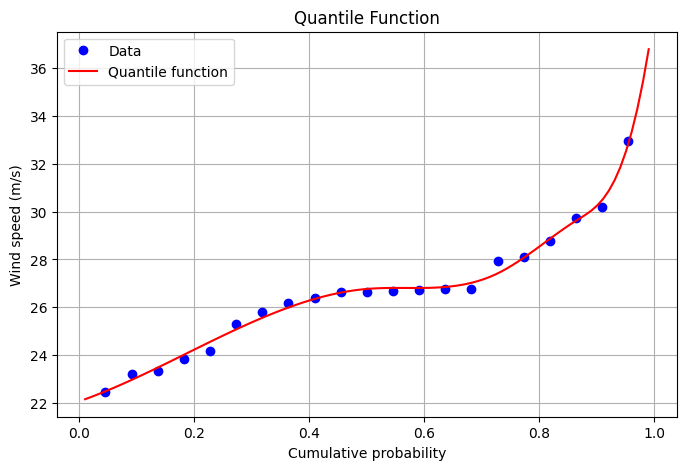

In [90]:
p_range = np.linspace(0.01, 0.99, 100)
plt.figure(figsize=(8, 5))
plt.plot(cprob, sorted_speeds, 'bo', label='Data')
plt.plot(p_range, quantile_func(p_range), 'r-', label='Quantile function')
plt.xlabel('Cumulative probability')
plt.ylabel('Wind speed (m/s)')
plt.title('Quantile Function')
plt.legend()
plt.grid(True)
plt.show()

### Summarize:
* importa tudo e escreve as funcoes
* lembrar que p tem que iterar para cada i - entao arange
* SORT MAX SPEEDS
* s = 0 para interpolar em todos os pontos
* quantile_func vai ser a Univariate Spline
* plotar cprob x sorted speeds
* plotar os pontos = linspance x quantile_func em cada ponto da cdf

## Curve fitting of temperature in Alaska

The temperature extremes in Alaska for each month, starting in January, are given by (in degrees Celcius):

max:  17,  19,  21,  28,  33,  38, 37,  37,  31,  23,  19,  18

min: -62, -59, -56, -46, -32, -18, -9, -13, -25, -46, -52, -58

* Plot these temperature extremes.
* Define a function that can describe min and max temperatures. 
* Fit this function to the data with scipy.optimize.curve_fit().
* Plot the result. Is the fit reasonable? If not, why?
* Is the time offset for min and max temperatures the same within the fit accuracy?

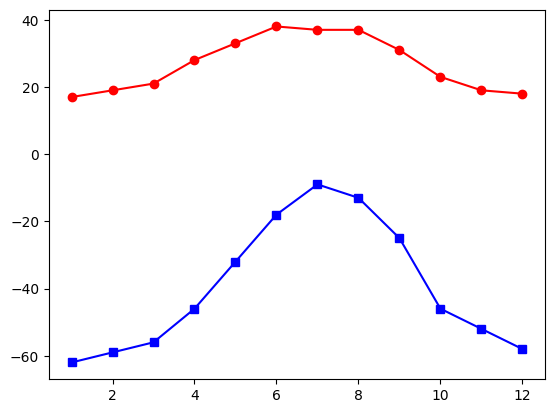

In [ ]:
max_temp = [17,  19,  21,  28,  33,  38, 37,  37,  31,  23,  19,  18]
min_temp = [-62, -59, -56, -46, -32, -18, -9, -13, -25, -46, -52, -58]
months = np.arange(1,13)

plt.plot(months, max_temp, 'ro-', label='Max Temp')
plt.plot(months, min_temp, 'bs-', label='Min Temp')



## FFT of an image

* Examine the provided image `moonlanding.png`, which is heavily contaminated with periodic noise. In this exercise, we aim to clean up the noise using the Fast Fourier Transform.
* Load the image using pylab.imread().
* Find and use the 2-D FFT function in scipy.fftpack, and plot the spectrum (Fourier transform of) the image. Do you have any trouble visualising the spectrum? If so, why?
* The spectrum consists of high and low frequency components. The noise is contained in the high-frequency part of the spectrum, so set some of those components to zero (use array slicing).
* Apply the inverse Fourier transform to see the resulting image.

In [99]:
import numpy as np
from scipy import fftpack
from matplotlib import pyplot as plt


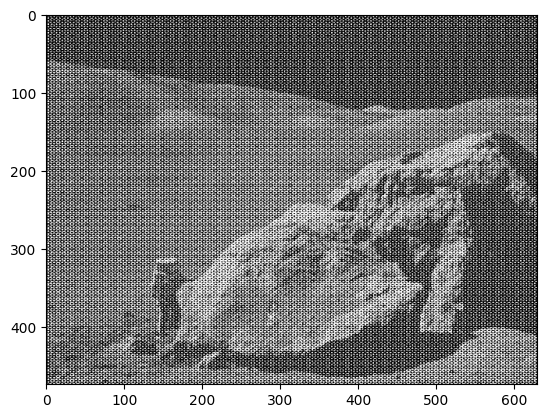

In [104]:
img = plt.imread("moonlanding.png", format='png')
plt.imshow(img, cmap='gray')

In [106]:
F = fftpack.fft2(img) #fft2 é pq é 2D
F_sifted = fftpack.fftshift(F) #shift the zero frequency component to the center of the spectrum